In [ ]:
# =====================================================
# EJERCICIO Bloque 7
# Autor: [Francisco Javier Tena Gómez] - Máster Ingeniería Biomédica - Técnicas Avanzadas de Análisis y Reconocimiento de Imágenes Biomédicas
# =====================================================

In [2]:

import sys
import platform

print("Entorno básico")
print(f"Python: {sys.version.split()[0]}")
print(f"SO: {platform.system()} {platform.release()} ({platform.version()})")
print(f"Arquitectura: {platform.machine()}")
print(f"Procesador: {platform.processor()}")


import torch, torchvision, numpy as np, matplotlib, sklearn, PIL, pandas as pd

print("Versiones de librerías")
print(f"PyTorch:       {torch.__version__}")
print(f"Torchvision:   {torchvision.__version__}")
print(f"NumPy:         {np.__version__}")
print(f"Matplotlib:    {matplotlib.__version__}")
print(f"scikit-learn:  {sklearn.__version__}")
print(f"Pillow (PIL):  {PIL.__version__}")
print(f"Pandas:        {pd.__version__}")


import torch

print("Aceleración (CUDA/cuDNN/GPU)")
print(f"CUDA disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Nº GPUs: {torch.cuda.device_count()}")
    idx = torch.cuda.current_device()
    print(f"GPU actual (índice): {idx}")
    print(f"Nombre GPU: {torch.cuda.getq_device_name(idx)}")
    print(f"Versión CUDA (compilada en PyTorch): {torch.version.cuda}")
    # cuDNN
    cudnn_enabled = torch.backends.cudnn.enabled
    cudnn_version = torch.backends.cudnn.version()
    print(f"cuDNN habilitado: {cudnn_enabled}")
    print(f"cuDNN versión: {cudnn_version}")
else:
    print("Se usará CPU para el entrenamiento/inferencia.")

    
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Dispositivo seleccionado en el cuaderno: {device}")


🧩 Entorno básico
Python: 3.6.13
SO: Windows 10 (10.0.26100)
Arquitectura: AMD64
Procesador: AMD64 Family 25 Model 117 Stepping 2, AuthenticAMD
📦 Versiones de librerías
PyTorch:       1.10.2
Torchvision:   0.11.3
NumPy:         1.19.2
Matplotlib:    3.3.4
scikit-learn:  0.24.2
Pillow (PIL):  6.2.1
Pandas:        1.1.5
⚙️ Aceleración (CUDA/cuDNN/GPU)
CUDA disponible: False
Se usará CPU para el entrenamiento/inferencia.
🖥️ Dispositivo seleccionado en el cuaderno: cpu


In [3]:
print("Dataset detectado:")
print("C:/workspaces/Jupyter/Kidney Disease Analysis/dataset/kidney-dataset/")

import os
import matplotlib.pyplot as plt
%matplotlib inline

# VERIFICAR estructura
dataset_path = r"C:\workspaces\Jupyter\Kidney Disease Analysis\dataset\kidney-dataset"
print("\n Carpetas encontradas:")
clases = ['Cyst', 'Normal', 'Stone', 'Tumor']
conteos = {}

for clase in clases:
    path = os.path.join(dataset_path, clase)
    if os.path.exists(path):
        imgs = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        conteos[clase] = len(imgs)
        print(f" {clase}: {len(imgs)} imágenes")
    else:
        print(f" {clase} NO encontrada")

print(f"\n TOTAL: {sum(conteos.values())} imágenes")
print(" ¡Dataset listo!")

Dataset detectado:
C:/workspaces/Jupyter/Kidney Disease Analysis/dataset/kidney-dataset/

 Carpetas encontradas:
 Cyst: 3709 imágenes
 Normal: 5077 imágenes
 Stone: 1377 imágenes
 Tumor: 2283 imágenes

 TOTAL: 12446 imágenes
 ¡Dataset listo!


MUESTRAS REPRESENTATIVAS (1x4 grid)


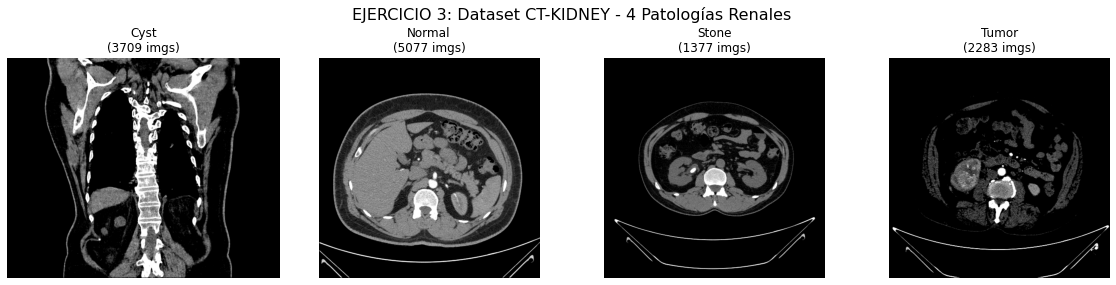

Screenshot PERFECTO (solo 4 imágenes arriba)


In [4]:
# CELDA 2: VISUALIZAR MUESTRAS CT RIÑÓN (1 fila, 4 imágenes)
print("MUESTRAS REPRESENTATIVAS (1x4 grid)")

import matplotlib.image as mpimg
dataset_path = r"C:\workspaces\Jupyter\Kidney Disease Analysis\dataset\kidney-dataset"
clases = ['Cyst', 'Normal', 'Stone', 'Tumor']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, clase in enumerate(clases):
    path = os.path.join(dataset_path, clase)
    img_files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    img_path = os.path.join(path, img_files[0])  # Primera imagen

    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f'{clase}\n({len(img_files)} imgs)')
    axes[i].axis('off')

plt.suptitle('EJERCICIO 3: Dataset CT-KIDNEY - 4 Patologías Renales', fontsize=16)
plt.tight_layout()
plt.show()

print("Screenshot PERFECTO (solo 4 imágenes arriba)")


In [5]:
# CELDA 3: TRANSFORMACIONES Y DATALOADERS
# En esta celda hemos preparado los datos para poder entrenar una red neuronal.
# Primero hemos definido unas transformaciones (redimensionar a 224×224, pequeñas rotaciones/flip y normalización) para homogeneizar todas las imágenes de TC.
#Después hemos cargado todas las imágenes de las cuatro clases desde las carpetas (Cyst, Normal, Stone, Tumor) y hemos dividido automáticamente el conjunto en entrenamiento (80%, 9.957 imágenes) y validación (20%, 2.489 imágenes), que usaremos para entrenar y evaluar la CNN

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dataset_path = r"C:\workspaces\Jupyter\Kidney Disease Analysis\dataset\kidney-dataset"

# Transformaciones: redimensionar y normalizar (tipo ImageNet)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# De momento, usamos todo como "train" y luego haremos split
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)
num_classes = len(full_dataset.classes)
print("Clases:", full_dataset.classes)
print("Total imágenes dataset:", len(full_dataset))

# Split train / val (80 / 20)
val_ratio = 0.2
num_val = int(len(full_dataset) * val_ratio)
num_train = len(full_dataset) - num_val
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [num_train, num_val],
    generator=torch.Generator().manual_seed(0)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)} imágenes")
print(f"Val:   {len(val_dataset)} imágenes")


Clases: ['Cyst', 'Normal', 'Stone', 'Tumor']
Total imágenes dataset: 12446
Train: 9957 imágenes
Val:   2489 imágenes


In [8]:
# CELDA 4: DEFINICIÓN DEL MODELO CNN
# En esta celda se ha definido la red neuronal convolucional (CNN) que usaremos para clasificar las imágenes de TC de riñón en cuatro clases (Cyst, Normal, Stone y Tumor).
# La arquitectura consta de tres bloques de convolución + pooling, que extraen progresivamente características visuales más complejas, y dos capas totalmente conectadas finales que transforman esas características en las puntuaciones (logits) para cada una de las cuatro clases.
import torch.nn as nn
import torch.nn.functional as F

class KidneyCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(KidneyCNN, self).__init__()
        
        # Bloque 1: detecta patrones básicos (bordes, contrastes)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)  # 224 -> 112
        
        # Bloque 2: patrones más complejos (formas de órganos/tejidos)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)  # 112 -> 56
        
        # Bloque 3: características de alto nivel
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)  # 56 -> 28
        
        # Capa totalmente conectada (clasificación final)
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Pasos de convolución + ReLU + pooling
        x = self.pool1(F.relu(self.conv1(x)))  # [3,224,224] -> [32,112,112]
        x = self.pool2(F.relu(self.conv2(x)))  # -> [64,56,56]
        x = self.pool3(F.relu(self.conv3(x)))  # -> [128,28,28]
        
        # Aplanar antes de las capas densas
        x = x.view(x.size(0), -1)
        
        # Clasificación
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)  # logits para 4 clases
        return x

# Instanciar modelo y mover a dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KidneyCNN(num_classes=4).to(device)
print(model)
print("\n Modelo listo en dispositivo:", device)


KidneyCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=4, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Modelo listo en dispositivo: cpu


In [9]:
# CELDA 5: ENTRENAMIENTO Y VALIDACIÓN DE LA CNN (CON TQDM)

import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm  # barra de progreso

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 3  # 3 épocas para que sea razonable en CPU

train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    print(f"\n Época {epoch+1}/{num_epochs}")
    for inputs, labels in tqdm(train_loader, desc=f"Entrenando época {epoch+1}", ncols=80):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Validación
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)
    print(f" Fin época {epoch+1}: loss={epoch_loss:.4f}  val_acc={val_acc:.2f}%")

print("\n Entrenamiento finalizado")



🔄 Época 1/3


Entrenando época 1: 100%|█████████████████████| 312/312 [36:43<00:00,  7.06s/it]


✅ Fin época 1: loss=0.6616  val_acc=89.71%

🔄 Época 2/3


Entrenando época 2: 100%|█████████████████████| 312/312 [07:22<00:00,  1.42s/it]


✅ Fin época 2: loss=0.2803  val_acc=95.26%

🔄 Época 3/3


Entrenando época 3: 100%|█████████████████████| 312/312 [07:21<00:00,  1.42s/it]


✅ Fin época 3: loss=0.1554  val_acc=97.19%

✅ Entrenamiento finalizado


In [ ]:
# El entrenamiento durante 3 épocas muestra una clara mejora del modelo. 
# La pérdida de entrenamiento desciende de 0.66 a 0.15 y la accuracy de validación aumenta desde el 89.71% hasta el 97.19%.
# Esto sugiere que la red neuronal convolucional es capaz de aprender características discriminativas
# de las imágenes de TC de riñón para separar correctamente las cuatro clases (Cyst, Normal, Stone y Tumor).

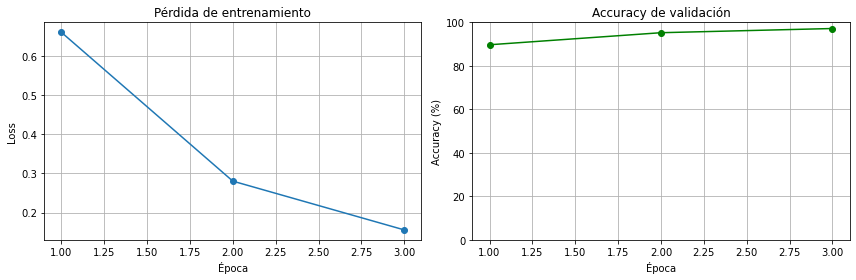

In [10]:
# CELDA 6: GRÁFICAS DE PÉRDIDA Y ACCURACY
# En esta celda se representan gráficamente la evolución de la pérdida de entrenamiento y de la accuracy de validación
# a lo largo de las épocas, para visualizar el comportamiento del aprendizaje de la CNN.
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,4))

# Pérdida
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o')
plt.title('Pérdida de entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)

# Accuracy validación
plt.subplot(1,2,2)
plt.plot(epochs, val_accuracies, marker='o', color='green')
plt.title('Accuracy de validación')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True)

plt.tight_layout()
plt.show()


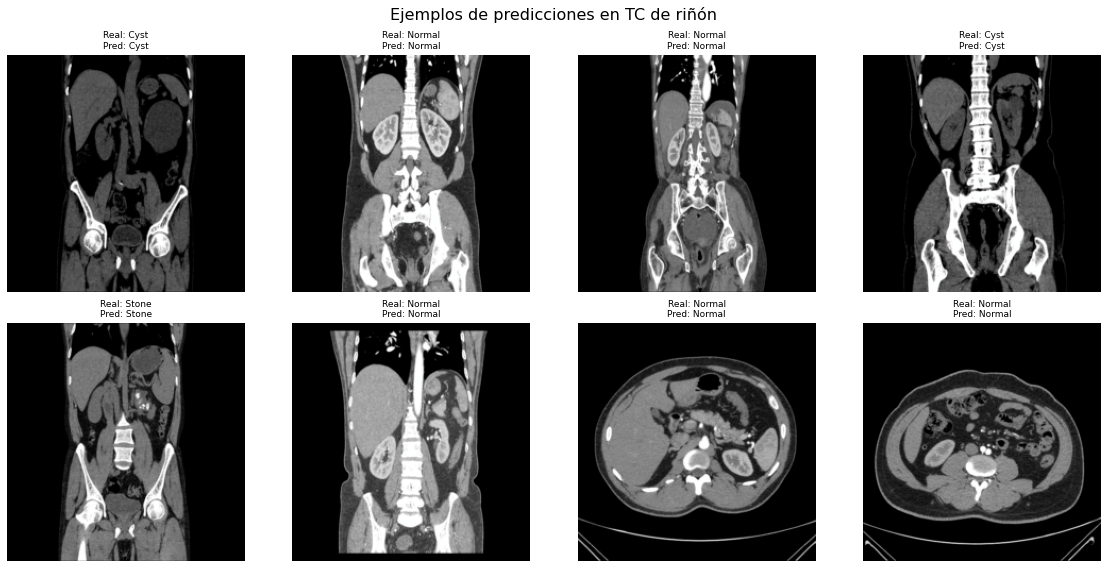

In [11]:
# CELDA 7: VISUALIZAR PREDICCIONES EN EL CONJUNTO DE VALIDACIÓN
# En esta celda se muestran algunas imágenes del conjunto de validación junto con su clase real y la clase predicha por el modelo.
# Esto permite comprobar de forma cualitativa el comportamiento de la CNN.

import numpy as np

# Poner el modelo en modo evaluación
model.eval()

# Necesitamos usar las mismas transformaciones de validación
val_dataset_eval = datasets.ImageFolder(dataset_path, transform=val_test_transform)
# Usamos unas pocas imágenes al azar
indices = np.random.choice(len(val_dataset_eval), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
class_names = full_dataset.classes  # ['Cyst', 'Normal', 'Stone', 'Tumor']

for ax, idx in zip(axes.flatten(), indices):
    img, label = val_dataset_eval[idx]
    img_batch = img.unsqueeze(0).to(device)  # añadir dimensión batch

    with torch.no_grad():
        outputs = model(img_batch)
        _, pred = torch.max(outputs, 1)

    # Convertir imagen de tensor normalizado a formato visualizable
    img_np = img.permute(1,2,0).cpu().numpy()
    # des-normalizar (aprox)
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    ax.imshow(img_np)
    ax.axis('off')
    ax.set_title(f"Real: {class_names[label]}\nPred: {class_names[pred.item()]}", fontsize=9)

plt.suptitle("Ejemplos de predicciones en TC de riñón", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# En las figuras, se muestran varios ejemplos del conjunto de validación.
# En la mayoría de los casos la clase predicha por la CNN coincide con la etiqueta real (por ejemplo, “Real: Cyst / Pred: Cyst”), 
# lo que ilustra la capacidad del modelo para reconocer correctamente las distintas patologías renales en las imágenes de TC.

<Figure size 432x432 with 0 Axes>

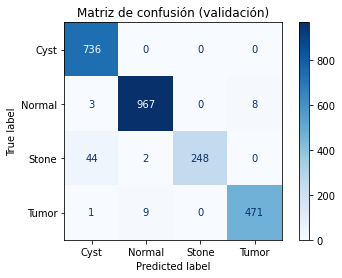

In [12]:
# CELDA 8: MATRIZ DE CONFUSIÓN EN VALIDACIÓN
# La matriz de confusión muestra cómo se distribuyen los aciertos y errores por clase.
# La mayoría de las imágenes se clasifican correctamente en su categoría (Cyst, Normal, Stone, Tumor),
# con pocos errores de confusión entre patologías, lo que refuerza la buena accuracy observada en validación (~97%).


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=full_dataset.classes)

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de confusión (validación)")
plt.show()


In [ ]:
# La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de los casos en todas las clases.
# Los quistes (Cyst) y las imágenes normales (Normal) se predicen casi siempre de forma correcta, 
# mientras que la clase Stone presenta algo más de confusión, principalmente con Cyst.
# Los tumores (Tumor) también se reconocen con alta precisión, con pocos casos confundidos con normalidad. 
# En conjunto, los errores son pocos y se concentran en clases con apariencia radiológica similar,
# lo que cuadra con la accuracy global de validación cercana al 97%.